<a href="https://colab.research.google.com/github/charlesdgburns/ring_attractors_and_rnns/blob/main/Ring_attractors_and_RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

A recent blogpost by Konrad Kording claims that ["Attractors are usually not mechanisms"](https://kording.substack.com/p/attractors-are-usually-not-mechanisms?r=ao63f&utm_campaign=post&utm_medium=web&triedRedirect=true).

**TLDR**: (please go read the blogpost, I can't do it justice in 15 lines)

Two words need clarifiation here:
- 'Attractors': referring to a neural network with dynamics such that the activity across all neurons that has stable points or basins of stable points (a mathematical object)
- 'mechanisms': referring to implementations of computation in the brain at the level of synaptic connectivity (a physiological object)

the blogpost supports its main claim by arguing with the head-direction circuit as an example:

1. Head-direction circuits found in brains can be described by 'attractors'
  - These attractors can be designed with specified connectivity (e.g. mexican-hat-like connectivity).

2. There is lacking evidence for 'mechanisms' of these attractors in the brain.
  - No strong evidence of mexican-hat-like connectivity or synaptic interactions accounting for it.

3. 'Non-Attractor Alternative': head-direction circuits exist in RNNs trained to integrate velocity.
  - in other words, attractors are not necessary for head-direction circuit activity.

4. Fitting RNN's to neurons can hallucinate attractors.
 - neural activity derived from a non-attractor mechanism can be described by attractor computations.




---
The blogpost is a great read - it helps us define and clarify what words we use when describing what's going on in our brains. Personally, I agree with points 1 and 2, I hadn't seen point 4 before, and I'm sceptical about point 3.

I don't think the argument that RNN's are 'Non-attractor' is valid.

 Konrad otherwise summarises this part of his argument quite elegantly:**"*The ugly duckling mimics the swan perfectly*"**. Here the *swan* is a simple and elegant head-direction attractor described by interactions between neurons (weights $w_{i,j}$ e.g. from a mexian-hat-like interaction kernel). The *ugly duckling* is an RNN which is trained to mimic a head-direction attractor (optimised to integrate velocity to predict head direction).

Let's take a closer look.

# The ugly duckling is a swan

We all know how the story ends. I've got a feeling that this story ends there too.

## the Swan: a ring attractor from simple interaction kernels.

Here we aim for a small replication of [Noorman et al., 2024](https://www.nature.com/articles/s41593-024-01766-5), demonstrating that small carefully designed neural networks can maintain head direction information.




/tmp/ipython-input-2-3726445188.py:63: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  w = fsolve(fixed_point_eq, np.pi/2, xtol=1e-12)[0]
/tmp/ipython-input-2-3726445188.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(w_pad = 10, h_pad =0)


Using parameters: JE=2.100, JI=-0.207 (boundary was 0.000)


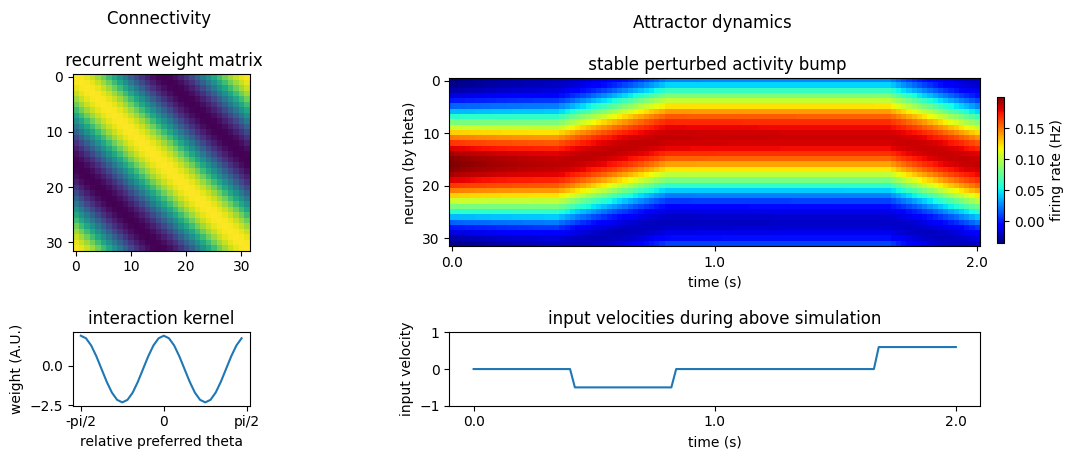

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize

## Functions ##

def simulate_network(W_sym, W_asym, h0, t, dt, theta, c_ff, vin):
    """Simulate network dynamics with exact connectivity"""
    N = len(theta)
    h = np.zeros((len(t), N))
    h[0] = h0
    psi = np.zeros(len(t))
    for i in range(1, len(t)):
        r = np.maximum(0, h[i-1]) # reLU activation
        total_input = (W_sym + vin[i] * W_asym) @ r / N #input defined by velocity and connectivity weights
        h[i] = h[i-1] + dt * (-h[i-1] + total_input + c_ff) / tau #euler update method
        # Compute bump phase
        r_current = np.maximum(0, h[i])
        if np.sum(r_current) > 1e-8:
            psi[i] = np.arctan2(np.sum(np.sin(theta) * r_current),np.sum(np.cos(theta) * r_current)) #
        else:
            psi[i] = psi[i-1]
    return np.unwrap(psi), h

def find_JI_boundary(JE, theta, cf):
    """Find JI boundary using contour method as described in the paper"""
    # Sample bump widths and orientations
    n_samples = 100
    psi_samples = np.linspace(0, 2*np.pi, n_samples, endpoint=False)
    w_samples = np.linspace(2*np.pi/len(theta), 2*(len(theta)-1)*np.pi/len(theta), n_samples)
    min_JI = 0 #for simplicity, consider only networks with negative inhibition
    for psi in psi_samples:
        for w in w_samples:
            # Calculate feven (equation S19)
            feven = np.mean(np.cos(theta - psi) * (np.cos(theta - psi) - np.cos(w/2)))
            # Only consider points on the JE*feven = 1 contour
            if abs(JE * feven - 1) > 1e-6:
                continue
            # Calculate f0 (equation S18)
            f0 = np.mean(np.cos(theta - psi) - np.cos(w/2))
            # Compute JI bound (equation 8)
            JI_candidate = -np.cos(w/2) / f0
            if JI_candidate < min_JI:
                min_JI = JI_candidate
    return min_JI

def find_JI_for_amplitude(JE, theta, cf, A_target, JI_bound):
    """Find JI that produces bump with amplitude ≈ A_target"""
    def objective(JI):
        h = initialize_bump(JE, JI, theta, cf, 0)
        current_amp = np.max(h)
        return (current_amp - A_target)**2
    # Search between reasonable bounds
    res = minimize(objective, x0=JI_bound-1, bounds=[(JI_bound-10, JI_bound+10)])
    return res.x[0]

def initialize_bump(JE, JI, theta, cf, psi0):
    """Initialize exact bump solution using current parameters"""
    # Solve for bump width w that satisfies fixed point condition
    def fixed_point_eq(w):
        feven = np.mean(np.cos(theta - psi0) * (np.cos(theta - psi0) - np.cos(w/2)))
        return JE * feven - 1
    w = fsolve(fixed_point_eq, np.pi/2, xtol=1e-12)[0]
    # Calculate bump profile
    f0 = np.mean(np.cos(theta - psi0) - np.cos(w/2))
    rho0 = -cf / (2 * (np.cos(w/2) + JI * f0))
    h = 2 * rho0 * (np.cos(theta - psi0) - np.cos(w/2))
    return h

## Example ##

# PARAMETERS #
N = 32                # Number of neurons
tau = 0.1             # Time constant (s)
c_ff = 0.1            # constant Feedforward input (example value > 0)
A_target = 0.2        # Target bump amplitude
JE = 2.1              # Local excitation (example value > 2)
dt = 0.02             # refresh rate in seconds (0.02~50Hz)
tmax = 2              # duration of simulation in seconds

# Neurons organised by preferred headings (evenly spaced)
theta = np.linspace(0, 2*np.pi, N, endpoint=False)
dtheta = theta[1] - theta[0]

# Finding JI which gives stable attractor dynamics is slightly tricky;
# we follow the methods in the paper
JI_bound = find_JI_boundary(JE, theta, c_ff)
JI = find_JI_for_amplitude(JE, theta, c_ff, A_target, JI_bound)
print(f"Using parameters: JE={JE:.3f}, JI={JI:.3f} (boundary was {JI_bound:.3f})")
# ! Now we can create connectivity matrices
W_sym = JI + JE * np.cos(theta[:,None] - theta[None,:])
W_asym = np.sin(theta[:,None] - theta[None,:])
# note: we can describe W_sym as an interaction between neurons of a given preferred orientation.
interaction_kernel = [W_sym[-x][x] for x in range(len(W_sym))]
# Initialize exact bump at 0 degree heading direction
h0 = initialize_bump(JE, JI, theta, c_ff, psi0=0)
# input velocities need to be given for each timestep in the simulation.
t = np.arange(0, tmax+dt, dt)
v_tile = [0,-0.5,0,0,0.6] #evenly tiles timesteps with velocities in list
input_velocities =  np.concat([np.tile(np.array(v_tile),
                                (int(np.ceil(len(t)/len(v_tile))),1))[:,i]
                               for i in range(len(v_tile))])
psi, h = simulate_network(W_sym, W_asym, h0, t, dt, theta, c_ff, vin=input_velocities)#

## Plotting ##
fig, ax = plt.subplots(2,2, figsize = (10,5),
                       width_ratios=(1,3), height_ratios=(1,1/5))
ax[0][0].set(title='Connectivity \n \n recurrent weight matrix')
ax[0][0].imshow(W_sym)

ax[1][0].set(title='interaction kernel',
             ylabel = 'weight (A.U.)',
             xlabel = 'relative preferred theta')
ax[1][0].plot(interaction_kernel)
ax[1][0].set_xticks([0,int(N/2),N],labels = ['-pi/2', 0,'pi/2'])


ax[0][1].set(title='Attractor dynamics \n \n stable perturbed activity bump',
             ylabel = 'neuron (by theta)',
             xlabel = 'time (s)')
ax[0][1].set_xticks([0, len(t)//2, len(t)-1], labels = t[[0,len(t)//2,-1]] )
bump_map = ax[0][1].imshow(h.T, cmap = 'jet')
fig.colorbar(bump_map,ax=ax[0][:], location='right', anchor = (2,0.5), shrink = 0.5, label = 'firing rate (Hz)')

ax[1][1].set(title='input velocities during above simulation',
             xlabel = 'time (s)',
             ylabel = 'input velocity',
             ylim = (-1,1))
ax[1][1].set_xticks([0, len(t)//2, len(t)-1], labels = t[[0,len(t)//2,-1]] )
ax[1][1].plot(input_velocities[:(len(t))])
fig.tight_layout(w_pad = 10, h_pad =0)

**Figure 1**: a simple network which balances global inhibition $J_I$ and a local excitatory excitation $J_E$ can achieve stable continuous attractor dynamics given velocity inputs.

The dynamics are goverened by:

In the weight matrix

In [ ]:
## You can interact with the network yourself - set the velocity and watch the bump go around the neurons arranged in a ring ! ##
import ipywidgets as widgets
import matplotlib as mpl

def update_plot(v_input, time_step):
    """Updates the plot with a new velocity input."""
    global current_vin # Use a global variable to store the current velocity input
    current_vin = -v_input # Update the global variable. flip sign so positive is clockwise and negative ccw
    psi, h = simulate_network(W_sym, W_asym, h0, t, dt, theta, c_ff, vin=np.repeat(current_vin, len(t)))
    plt.clf() #clear previous plot
    ax = plt.subplot(111, projection='polar')
    # Set the color map
    norm = mpl.colors.Normalize(vmin=0, vmax=A_target)
    cmap = mpl.cm.viridis
    # Plot the neurons as colored points on the circle
    ax.scatter(theta, np.ones_like(theta), c=h[time_step], cmap=cmap, norm=norm, s=100, edgecolors='k')
    ax.axis('off')
    # Add a colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, label='Activity', ax=ax, shrink=0.7)

    plt.show()

# Display the interactive plot
widgets.interact(update_plot,v_input=(-1,1,0.1), time_step=widgets.Play(min=0,max=len(t)-1));
# You'll have to hit play to watch the animation - in google colab this play button is sometimes hidden but still functional.
# (it's placed lower left of the 'v_input' label)


## the Ugly Duckling: an RNN trained to integrate velocity to predict head direction

In [ ]:
# prompt: Train a simple RNN to integrate velocity input (scalar radians per second) to  predict head direction (circular -pi/2 to pi/2). The head direction data should be generated with sparse movements (velocity =0 half the time). The model needs an encoder, so that at the start of each sequence, the initial head direction needs to be encoded into the hidden state (making the first initial state). Then velocity at t should be fed in to predict head direction at t+1 along the sequence.
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Check for CUDA availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# 1. Data Generation
def generate_head_direction_data(num_sequences, seq_len, dt, movement_sparsity=0.5):
    initial_hds = np.zeros((num_sequences,2))
    velocities = np.zeros((num_sequences, seq_len))
    head_directions = np.zeros((num_sequences, seq_len,2))

    for i in range(num_sequences):
        initial_direction = np.random.uniform(-np.pi, np.pi)
        initial_hds[i,0],initial_hds[i,1] = (np.cos(initial_direction),np.sin(initial_direction))
        current_direction = initial_direction

        for t in range(seq_len):
            if np.random.rand() > movement_sparsity:
                velocity = np.random.uniform(-1, 1)  # Example velocity range in radians / s
            else:
                velocity = 0.0

            velocities[i, t] = velocity
            # Integrate velocity to get the next head direction
            current_direction += velocity
            current_direction = current_direction %(2*np.pi)
            head_directions[i, t,0], head_directions[i,t,1] = (np.cos(current_direction),np.sin(current_direction))

    return velocities, head_directions, initial_hds

# Dataset class for PyTorch
class HeadDirectionDataset(Dataset):
    def __init__(self, velocities, head_directions, initial_hds):
        self.velocities = torch.tensor(velocities, dtype=torch.float32)
        self.head_directions = torch.tensor(head_directions, dtype=torch.float32)
        self.initial_hds = torch.tensor(initial_hds, dtype = torch.float32)
    def __len__(self):
        return len(self.velocities)
    def __getitem__(self, idx):
        initial_hd = self.initial_hds[idx] # Shape (1,)
        velocities = self.velocities[idx]     # Shape (seq_len,)
        target_hd = self.head_directions[idx]  # Shape (seq_len,)
        return initial_hd, velocities, target_hd


# 2. Model Definition
class HeadDirectionRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(HeadDirectionRNN, self).__init__()
        self.hidden_size = hidden_size
        self.encoder = nn.Linear(output_size, hidden_size)
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='relu')
        self.decoder = nn.Linear(hidden_size, output_size)

    def forward(self, initial_hd, velocities):
        batch_size = initial_hd.size(0)
        seq_len = velocities.size(1)
        #first, reset head-direction encoding (linear)
        h0 = self.encoder(initial_hd) # Shape (batch_size, hidden_size)
        h0 = h0.unsqueeze(0) # Shape (1, batch_size, hidden_size)
        # RNN forward pass
        # velocities shape (batch_size, seq_len) -> (batch_size, seq_len, 1) for RNN input
        rnn_input = velocities.unsqueeze(-1)
        rnn_output, _ = self.rnn(rnn_input, h0) # rnn_output shape (batch_size, seq_len, hidden_size)
        # Decode the RNN output at each time step to predict the next head direction
        predicted_hd = self.decoder(rnn_output) # Shape (batch_size, seq_len, output_size)
        return predicted_hd


# 3. Training Setup
input_size = 1  # Velocity is scalar
hidden_size = 64 # N_neurons
output_size = 2 # Predicted head direction is encoded in cos, sin coordinates
dt = 0.02 # Smaller dt might make integration easier
movement_sparsity = 0.5
num_sequences = 10000
seq_len = 100
num_epochs = 100
batch_size = 32
learning_rate = 3e-4
weight_decay = 1e-3

# Prepare data
velocities, head_directions, initial_hds = generate_head_direction_data(num_sequences, seq_len, dt, movement_sparsity)
dataset = HeadDirectionDataset(velocities, head_directions, initial_hds)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model, loss function, and optimizer
model = HeadDirectionRNN(input_size, hidden_size, output_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
compute_mse = nn.MSELoss()
# 4. Training Loop
mse_losses = []
weight_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    mse_loss = 0
    for initial_hd, velocities_batch, target_hd_batch in dataloader:
        # Move data to the selected device
        initial_hd = initial_hd.to(device)
        velocities_batch = velocities_batch.to(device)
        target_hd_batch = target_hd_batch.to(device)
        # reset optimier, compute loss, do autograd
        optimizer.zero_grad()
        predicted_hd = model(initial_hd, velocities_batch)
        mse_loss = compute_mse(predicted_hd, target_hd_batch)
        #weight_loss = weight_decay*torch.abs(model.rnn.weight_hh_l0).sum()
        loss = mse_loss #+ weight_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        #weight_losses.append(weight_loss.detach().cpu().item())
        mse_losses.append(mse_loss.detach().cpu().item())
    # Print average loss for the epoch
    avg_loss = total_loss / len(dataloader)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

print("Training finished.")

Using device: cuda
Epoch [10/100], Loss: 0.0431
Epoch [20/100], Loss: 0.0139
Epoch [30/100], Loss: 0.0089
Epoch [40/100], Loss: 0.0053
Epoch [50/100], Loss: 0.0045
Epoch [60/100], Loss: 0.0049
Epoch [70/100], Loss: 0.0040
Epoch [80/100], Loss: 0.0037
Epoch [90/100], Loss: 0.0035
Epoch [100/100], Loss: 0.0032
Training finished.


In [ ]:
# show data #

head_directions_in_rad =np.concatenate( np.atan2(head_directions[:,:,1],head_directions[:,:,0]) )


[Text(0.5, 1.0, 'weight loss'), Text(0.5, 0, 'bptt iteration')]

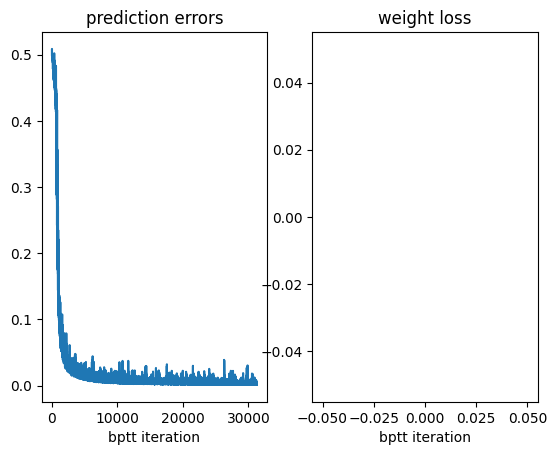

In [ ]:
fig, ax = plt.subplots(1,2)
ax[0].plot(mse_losses)
ax[0].set(title = 'prediction errors', xlabel='bptt iteration')
ax[1].plot(weight_losses)
ax[1].set(title='weight loss', xlabel='bptt iteration')

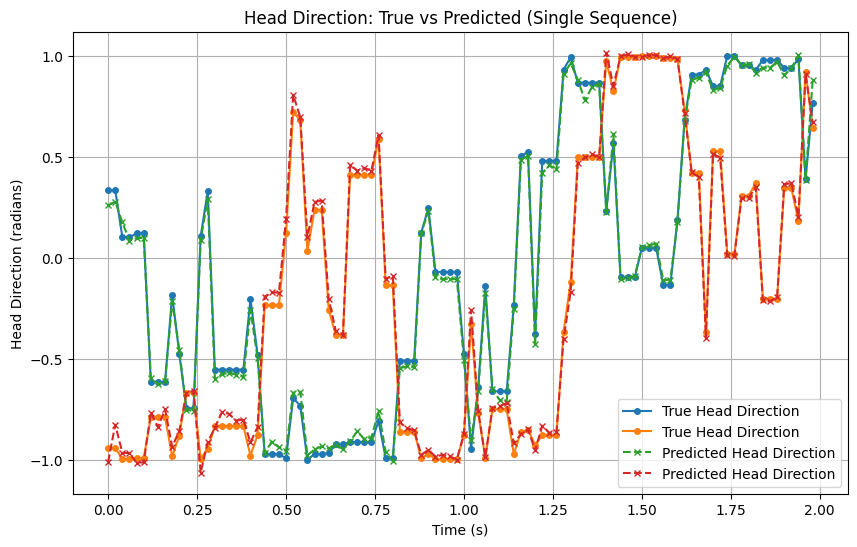

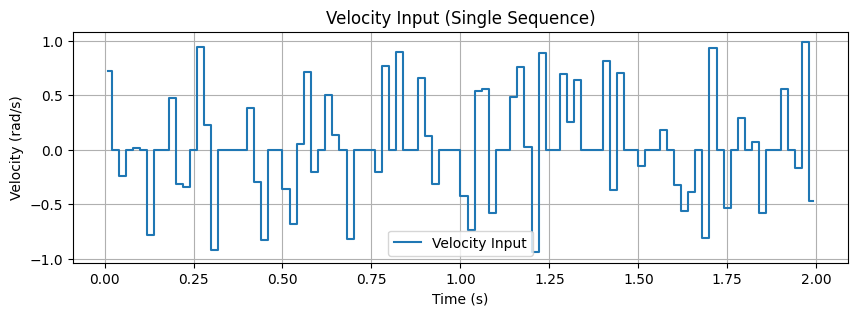

In [ ]:
import matplotlib.pyplot as plt
# 5. Evaluation (Optional)
model.eval()
with torch.no_grad():
    # Take one sequence from the training data for visualization
    initial_hd_eval, velocities_eval, target_hd_eval = dataset[0]
    initial_hd_eval = initial_hd_eval.unsqueeze(0).to(device) # Add batch dimension
    velocities_eval = velocities_eval.unsqueeze(0).to(device) # Add batch dimension

    predicted_hd_eval = model(initial_hd_eval, velocities_eval).squeeze(0).cpu().numpy()

    # Plotting the results for one sequence
    plt.figure(figsize=(10, 6))
    true_hd_sequence = target_hd_eval.cpu().numpy()
    predicted_hd_sequence = (predicted_hd_eval)

    time_steps = np.arange(seq_len) * dt

    plt.plot(time_steps, true_hd_sequence, label='True Head Direction', marker='o', linestyle='-', markersize=4)
    plt.plot(time_steps, predicted_hd_sequence, label='Predicted Head Direction', marker='x', linestyle='--', markersize=4)
    plt.title('Head Direction: True vs Predicted (Single Sequence)')
    plt.xlabel('Time (s)')
    plt.ylabel('Head Direction (radians)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot velocity input for the same sequence
    plt.figure(figsize=(10, 3))
    # Velocity input is for t=0 to t=seq_len-2, affecting t=1 to t=seq_len-1
    velocity_time_steps = time_steps[:] + dt/2 # Plot velocity roughly in the middle of the interval it applies
    plt.step(velocity_time_steps, velocities_eval.squeeze().cpu().numpy(), where='mid', label='Velocity Input')
    plt.title('Velocity Input (Single Sequence)')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (rad/s)')
    plt.legend()
    plt.grid(True)
    plt.show()

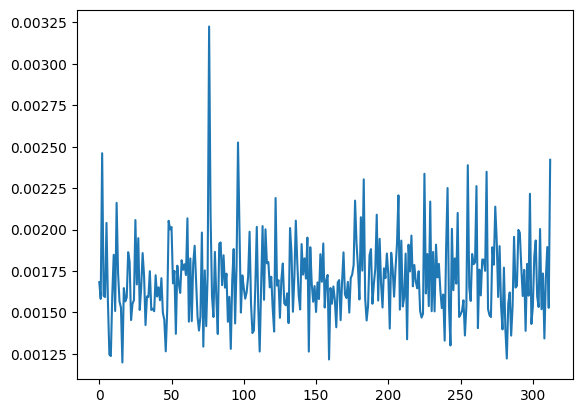

In [ ]:
# Validation and hidden unit activity #

# Prepare data (gnerating new dataset similar to training data)
val_vel, val_hd, val_initial_hds = generate_head_direction_data(num_sequences, seq_len, dt, movement_sparsity)
val_dataset = HeadDirectionDataset(val_vel, val_hd, val_initial_hds)
val_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 4. inspecting hidden activities
hidden_states = []
hd_at_hidden = []
val_loss = []

model.eval()
with torch.no_grad():
    for initial_hd, velocities_batch, target_hd_batch in val_dataloader:
        # Move data to the selected device
        initial_hd = initial_hd.to(device)
        velocities_batch = velocities_batch.to(device)  #(batch_size,seq_length)
        target_hd_batch = target_hd_batch.to(device)  #(batch_size, seq_length, 2)
        predicted_directions = []
        for i in range(seq_len):
           # Process one time step at a time
          current_velocity = velocities_batch[:, i].reshape(velocities_batch.shape[0],1,1) # Shape (batch_size, 1, 1)
          if i == 0:
            h = model.encoder(initial_hd).unsqueeze(0) #(1, batch_size, hidden_size)
            hd_at_hidden.append(initial_hd.cpu().numpy())
          else:
            hd_at_hidden.append(target_hd_batch[:,i,:].cpu().numpy())
          rnn_output, h = model.rnn(current_velocity, h) # rnn_output shape (batch_size, 1, hidden_size), h shape (1, batch_size, hidden_size)
          hidden_states.append(h.squeeze(0).cpu().numpy())
          predicted_directions.append(model.decoder(rnn_output))
        val_loss.append(compute_mse(torch.concat(predicted_directions, axis =1), target_hd_batch).cpu().item())

plt.plot(val_loss)

In [ ]:
val_hds = np.atan2(np.concat(hd_at_hidden)[:,1],np.concat(hd_at_hidden)[:,0]) #(n_steps,1)
hidden_states = np.concat(hidden_states) #(n_steps, n_hidden)

# Bin head directions
num_bins = 36  # Choose the number of bins
bins = np.linspace(-np.pi, np.pi, num_bins + 1)
head_direction_bins = np.digitize(val_hds, bins) - 1 # -1 to get 0-indexed bins

# Calculate mean firing rate for each bin for each neuron
mean_firing_rates = np.zeros((hidden_size, num_bins))
for unit_idx in range(hidden_size):
    for bin_idx in range(num_bins):
        # Find the indices of time points where the head direction is in the current bin
        indices_in_bin = np.where(head_direction_bins == bin_idx)[0]
        if len(indices_in_bin) > 0:
            # Calculate the mean activity of the current neuron at these time points
            mean_firing_rates[unit_idx, bin_idx] = np.mean(hidden_states[indices_in_bin, unit_idx])
        else:
            mean_firing_rates[unit_idx, bin_idx] = np.nan # Assign 0 if no data in

# cell classification #

hd_score =

In [ ]:
bin_size = np.diff(bins).mean()*
bin_size

np.float64(0.17453292519943295)

(array([ 5.,  3.,  1.,  4.,  9., 11., 12.,  7.,  5.,  7.]),
 array([0.01453864, 0.0777356 , 0.14093256, 0.20412952, 0.26732647,
        0.33052343, 0.39372039, 0.45691734, 0.5201143 , 0.58331126,
        0.64650822]),
 <BarContainer object of 10 artists>)

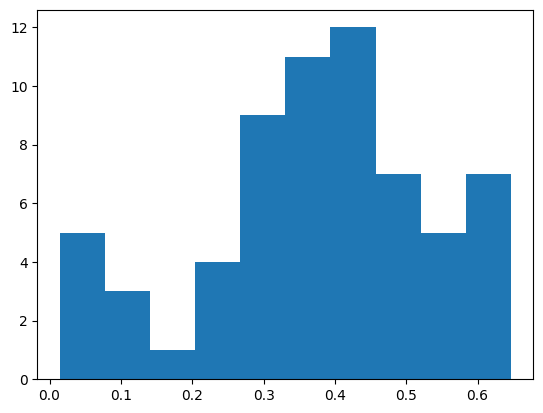

In [ ]:
plt.hist(mean_firing_rates.max(axis=1)/mean_firing_rates.mean(axis=1))

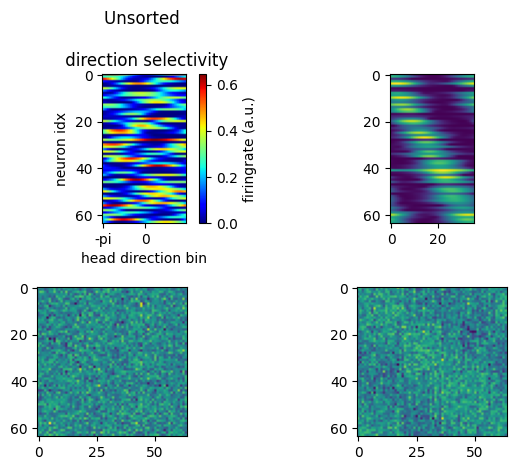

In [ ]:
sorted_unit_idx = np.argsort(mean_firing_rates.argmax(axis=1))
sorted_fr = np.zeros(mean_firing_rates.shape)
sorted_fr = mean_firing_rates[sorted_unit_idx,:]
sorted_weights = np.zeros((64,64))
unsorted_weights = model.rnn.weight_hh_l0.detach().cpu().numpy()
for i in range(hidden_size):
  for j in range(hidden_size):
    sorted_weights[i,j] = unsorted_weights[sorted_unit_idx[i],sorted_unit_idx[j]]

fig, ax = plt.subplots(2,2)
ax[0][0].set(title = 'Unsorted \n \n direction selectivity',
          xlabel = 'head direction bin',
          ylabel = 'neuron idx')
ax[0][0].set_xticks([0,int(num_bins/2),num_bins], labels = ['-pi',0,'pi'])

fr = ax[0][0].imshow(mean_firing_rates, cmap = 'jet')
fig.colorbar(fr, ax = ax[0][0], label = 'firingrate (a.u.)')
fig.tight_layout()

ax[1][0].set(title = 'Sorted \n \n direction selectivity',
             ylabel = 'selective phase')
ax[1][0].imshow(unsorted_weights)

ax[0][1].imshow(sorted_fr)
ax[1][1].imshow(sorted_weights)

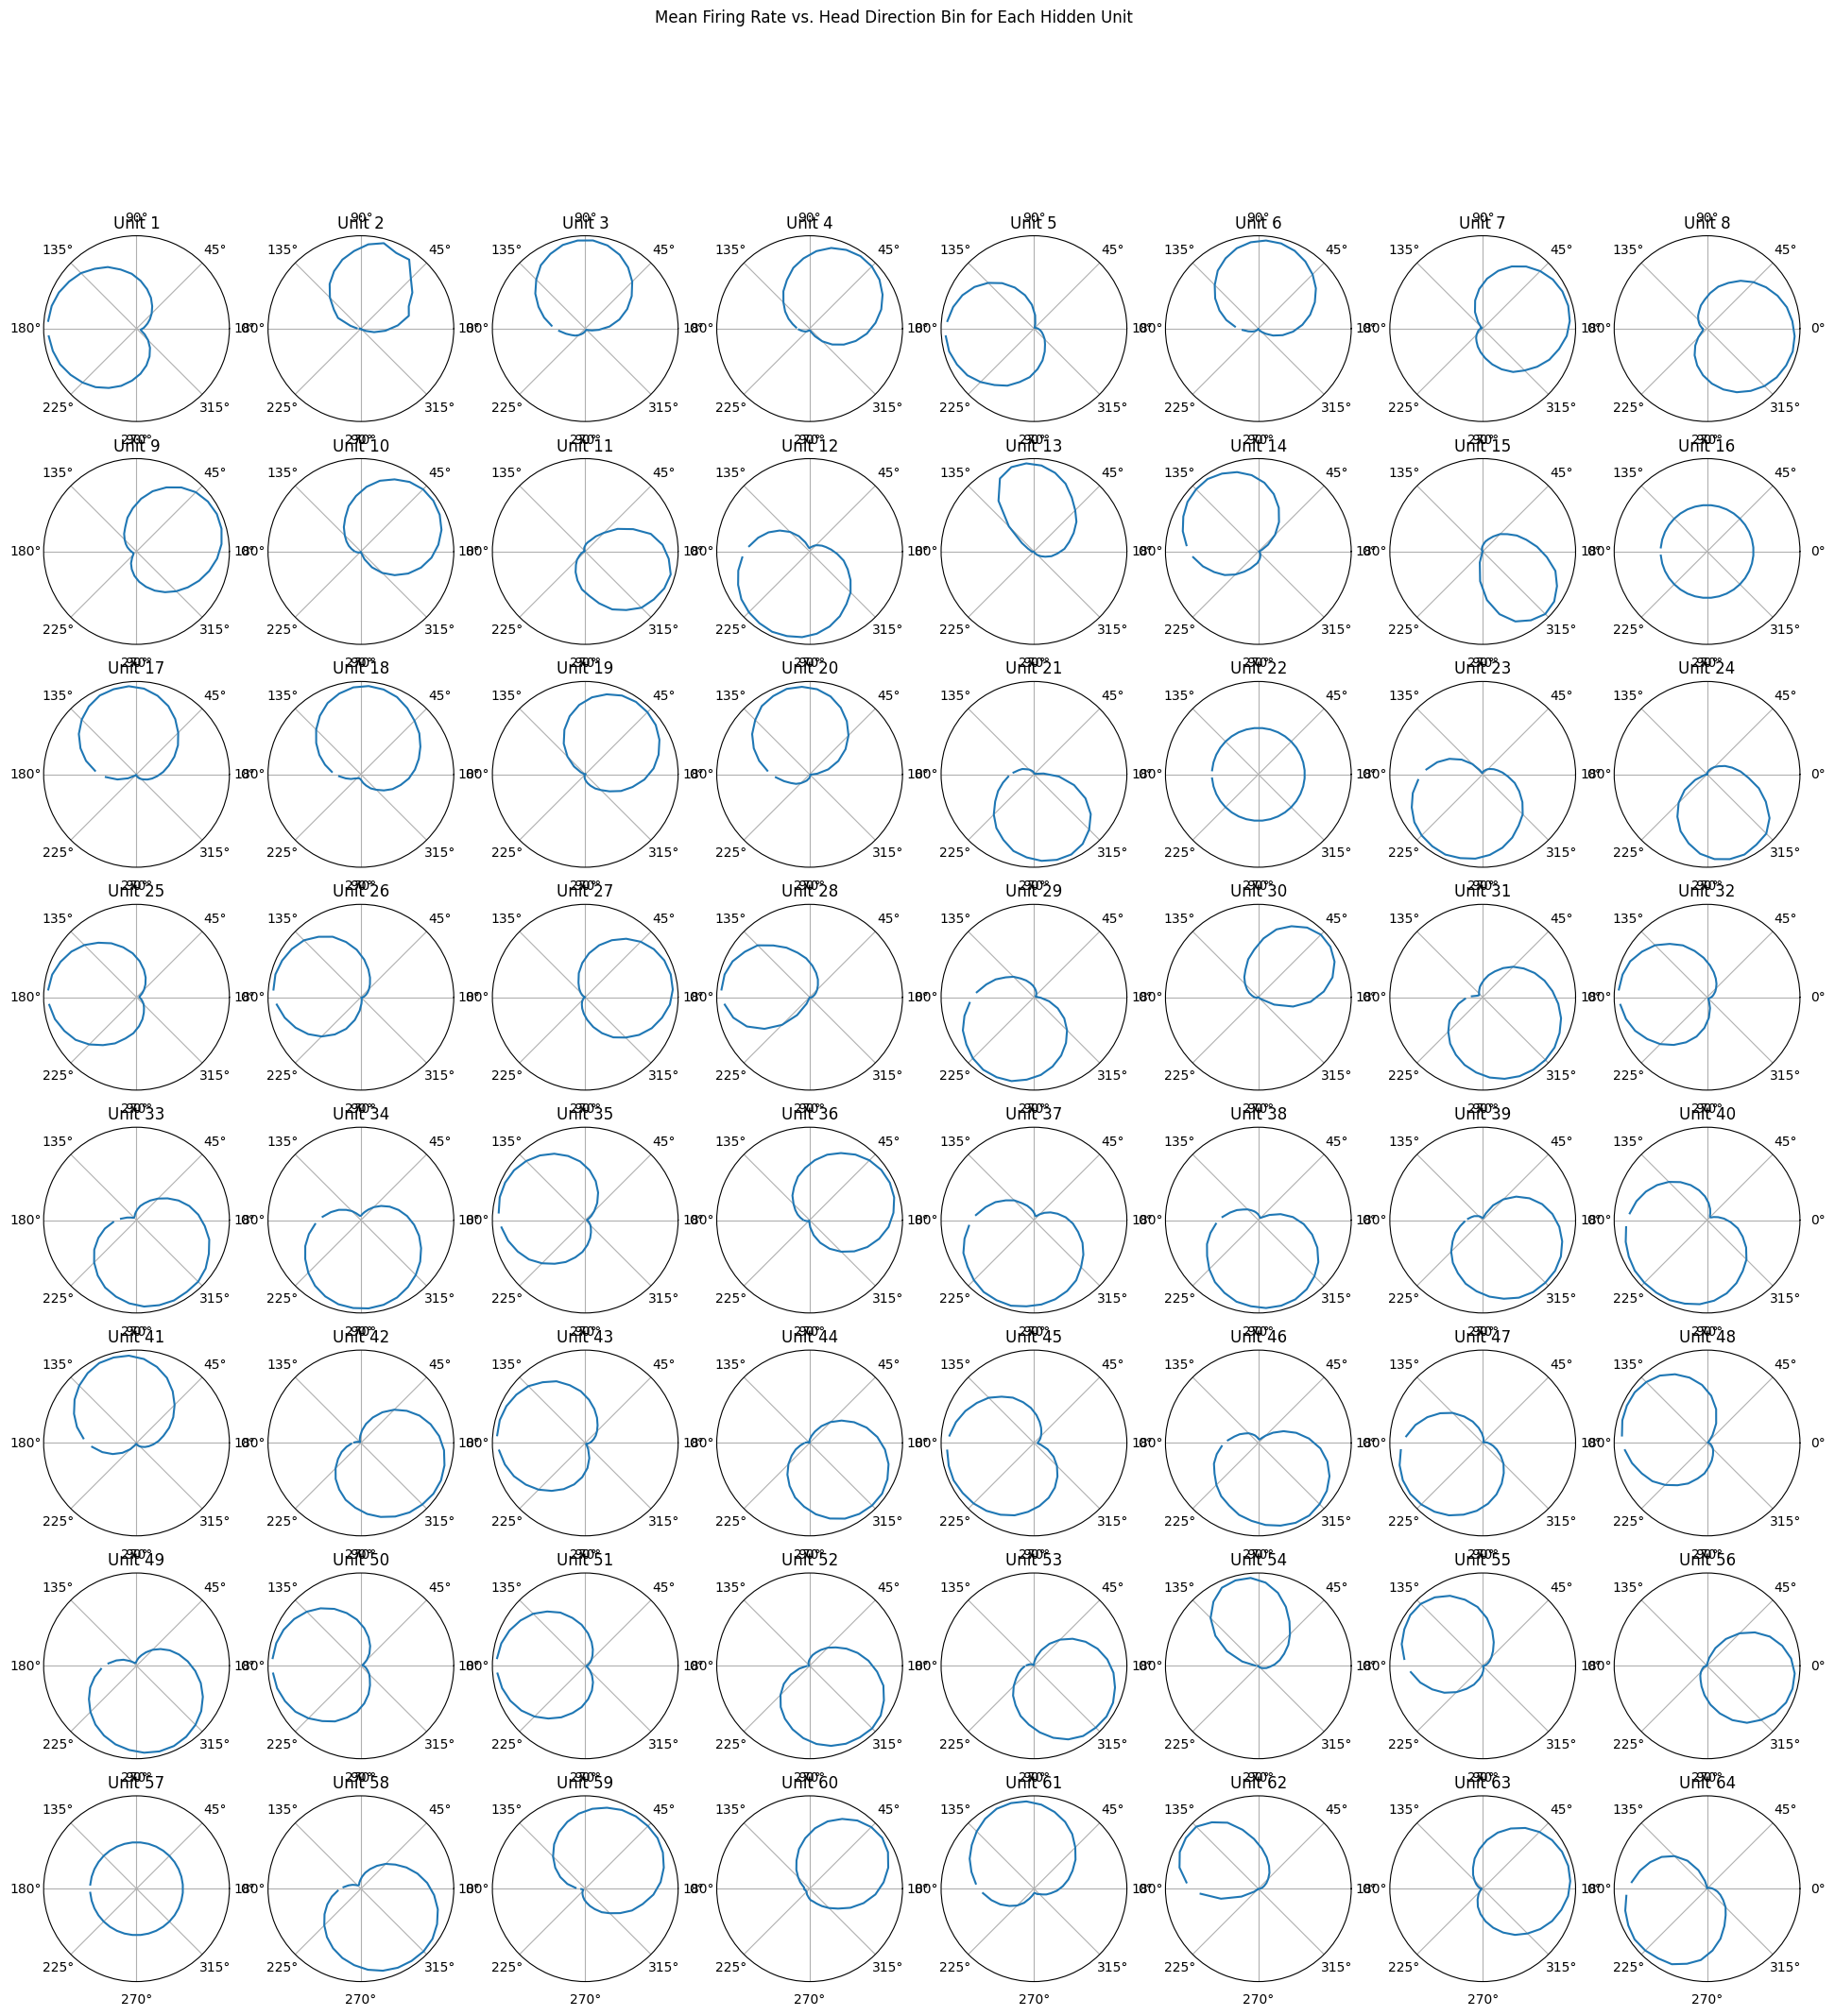

In [ ]:
# prompt: bin the head_directions into different head directions, then for each neuron find the mean firing rate for each bin. Show me a plot of each neuron's tuning to different head directions throughout the entire trajectory

# Plot tuning curves for each neuron
num_cols_tuning = 8
num_rows_tuning = (hidden_size + num_cols_tuning - 1) // num_cols_tuning

plt.figure(figsize=(num_cols_tuning * 3, num_rows_tuning * 3))

bin_centers = (bins[:-1] + bins[1:]) / 2

for unit_idx in range(hidden_size):
    plt.subplot(num_rows_tuning, num_cols_tuning, unit_idx + 1, projection='polar')
    plt.plot(bin_centers, mean_firing_rates[unit_idx, :])
    plt.title(f'Unit {unit_idx+1}')
    plt.yticks([])  # Hide radial ticks

plt.suptitle('Mean Firing Rate vs. Head Direction Bin for Each Hidden Unit', y=0.98)
plt.show()
